In [2]:
import os
import csv

# 数据目录路径
data_dir = "../../python_code/experiment_1/run01"

# 初始化字典
data_dict = {}

# 遍历目录下所有 CSV 文件
for filename in sorted(os.listdir(data_dir)):
    if not filename.endswith(".csv"):
        continue
    
    filepath = os.path.join(data_dir, filename)
    
    # 去掉 .csv 后缀作为字典的键
    key = filename[:-4]  # 去掉最后的 ".csv"
    
    theta_1_list = []
    theta_2_list = []
    
    with open(filepath, 'r') as f:
        reader = csv.reader(f)
        next(reader)  # 跳过表头
        for row in reader:
            theta_1_list.append(float(row[0]))
            theta_2_list.append(float(row[1]))
    
    data_dict[key] = [theta_1_list, theta_2_list]

#这一块是Continue Agent Vibe出来的，因为我懒的弄这些，并且这块跟美学设计没关系，也不影响结果，所以我觉得问题不大，有正当理由不算学术不端。

<positron-console-cell-23>:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


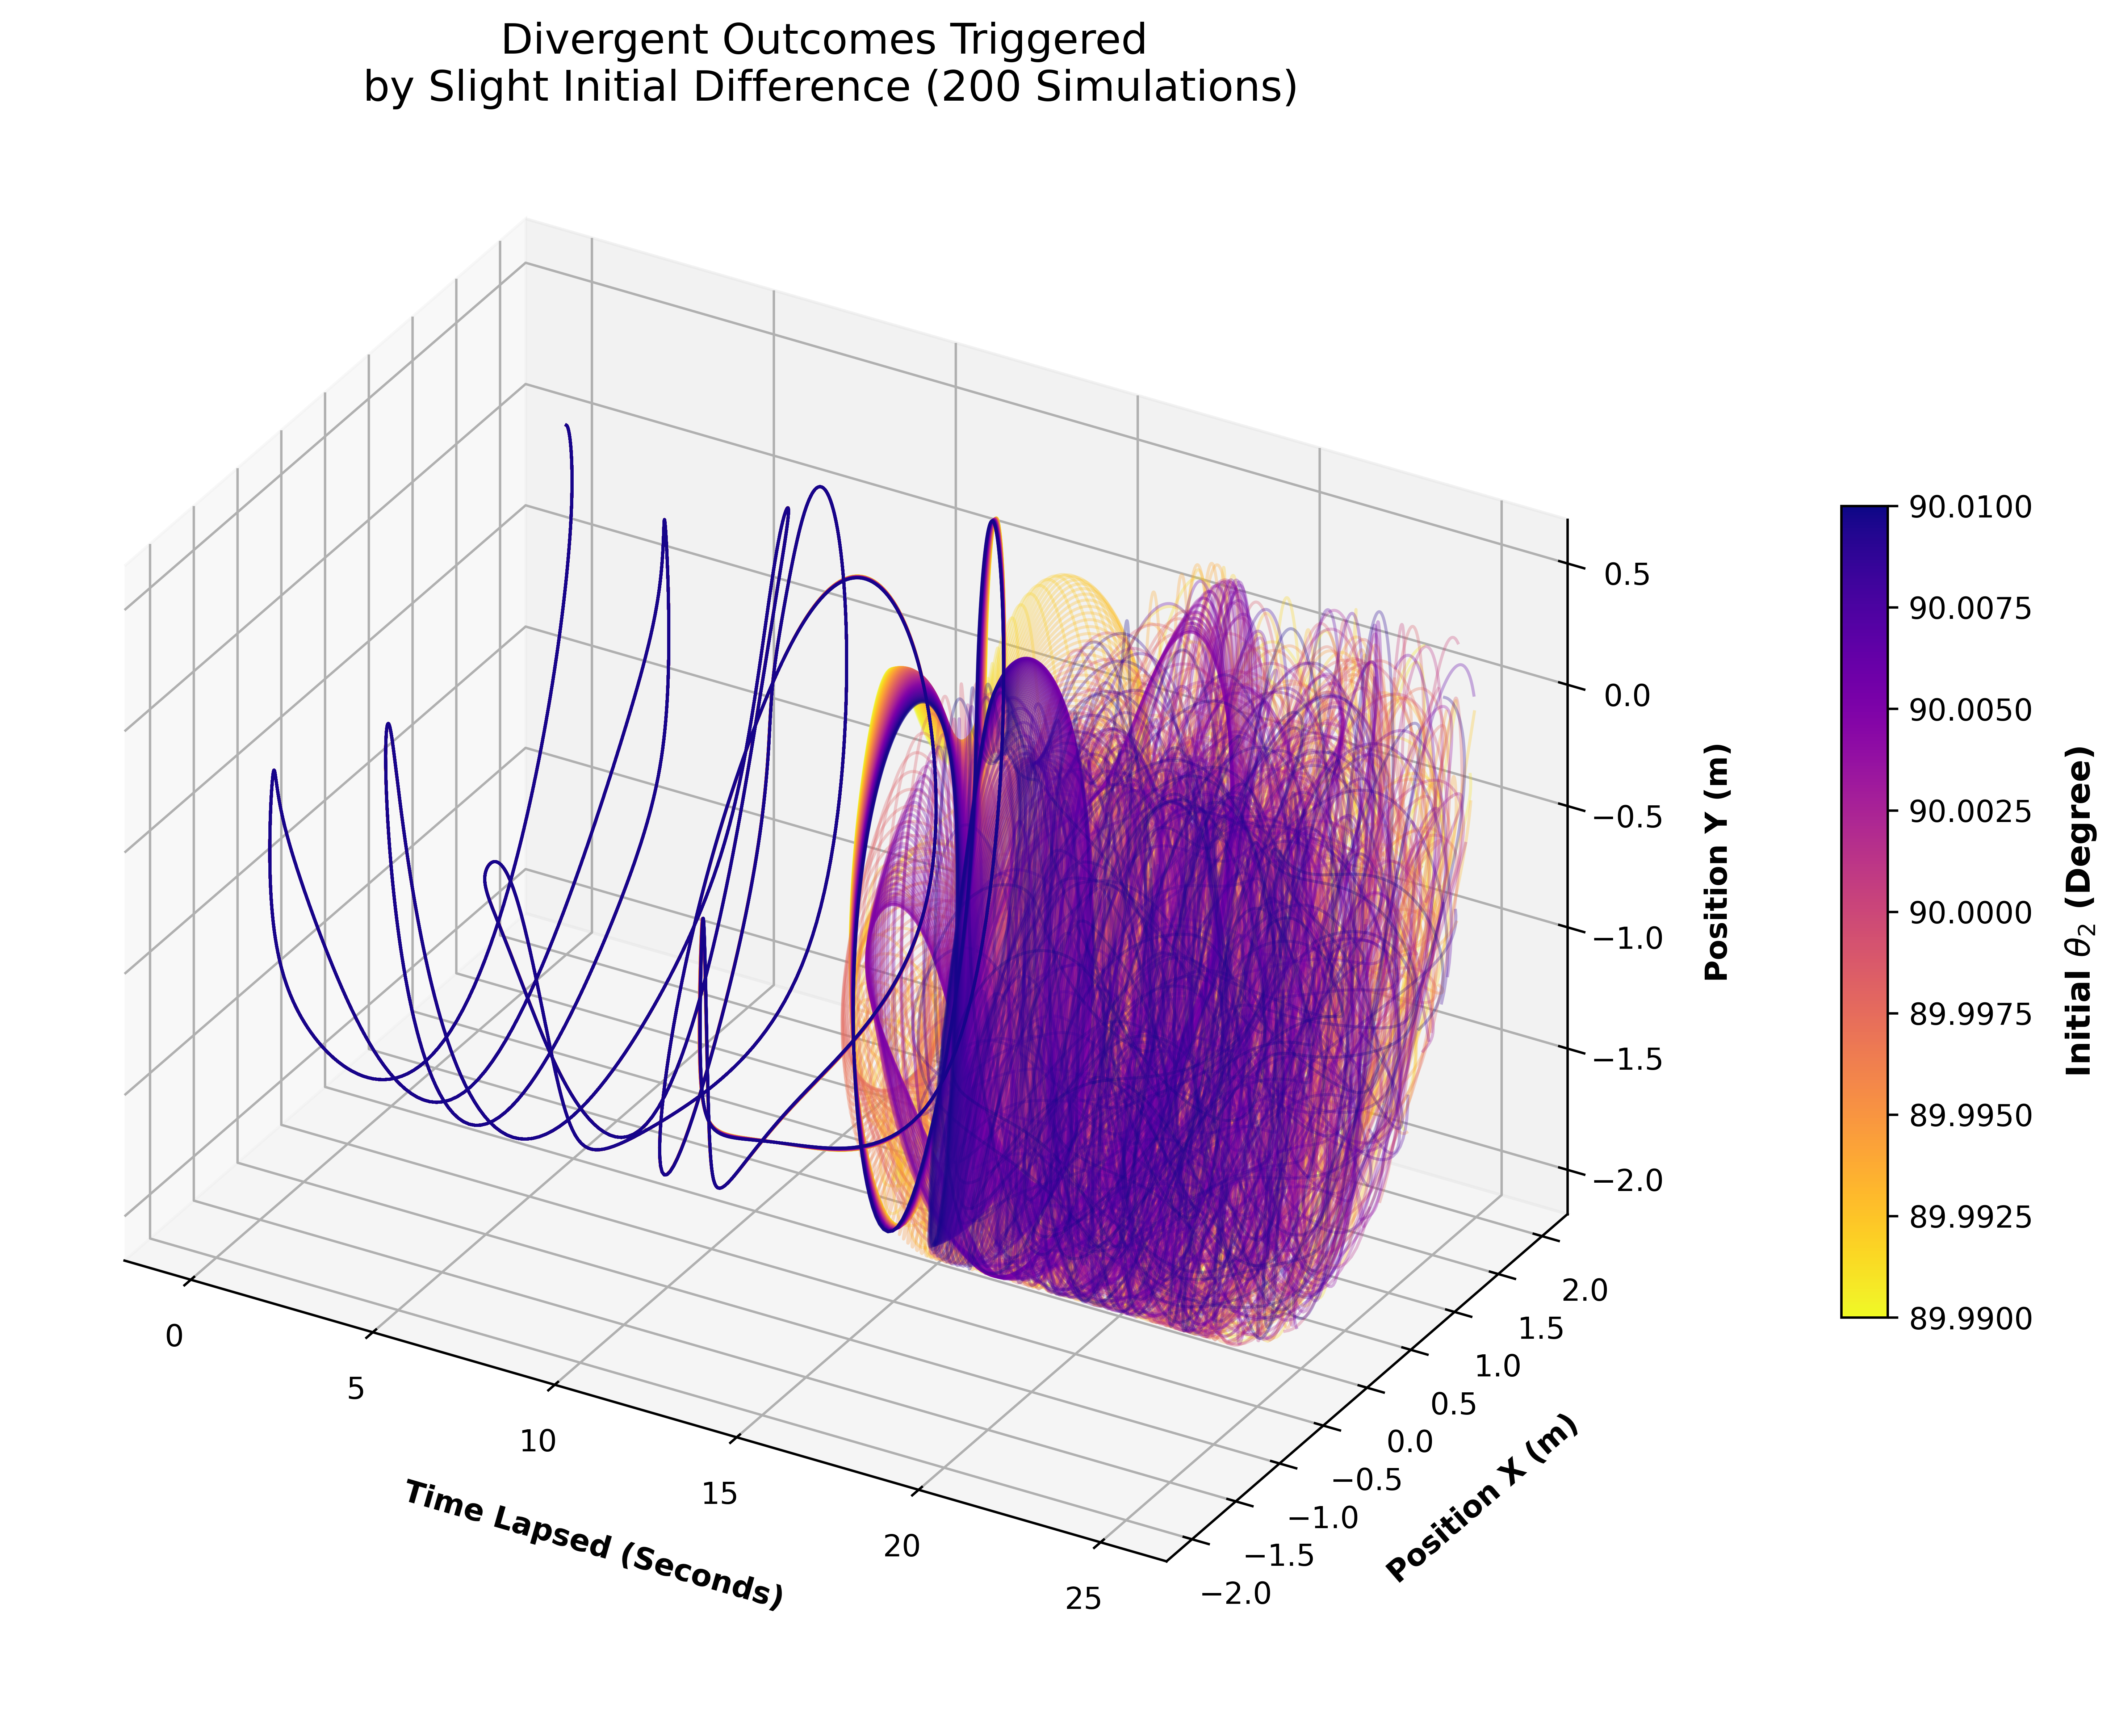

In [23]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# 1. 创建画布与 3D 正交坐标系
fig = plt.figure(figsize=(10, 8), dpi=600) 
ax = plt.axes(projection='3d', proj_type='ortho')
ax.set_box_aspect((1.5, 1, 1)) 

# 2. 设置颜色映射 (Colormap)
vmin, vmax = 89.9900, 90.0100
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.get_cmap('plasma_r')

dt = 0.01 
sorted_keys = sorted(data_dict.keys())
total_lines = len(sorted_keys)

# 3. 循环遍历 200 组数据并进行物理坐标转换
for i, key in enumerate(sorted_keys):
    # 从字典拿到存好的 theta_1 和 theta_2 列表 (度数)
    theta1_deg = np.array(data_dict[key][0])
    theta2_deg = np.array(data_dict[key][1])
    
    # 转换为弧度 (Radiand)，对应你代码里的 math.radians
    theta1_rad = np.radians(theta1_deg)
    theta2_rad = np.radians(theta2_deg)
    

    posx = np.sin(theta1_rad) + np.sin(theta2_rad)
    posy = -1.0 * np.cos(theta1_rad) - np.cos(theta2_rad)
    
    # 自动生成时间轴
    time = np.arange(len(posx)) * dt
    
    # 从文件名提取当前 theta2_0 数值用于匹配 Colorbar
    try:
        current_theta2 = float(key.split('_')[-1])
    except ValueError:
        current_theta2 = vmin + (vmax - vmin) * (i / (total_lines - 1))
        
    line_color = cmap(norm(current_theta2))
    
    # 画出真正的 3D 轨迹图 (X轴=时间, Y轴=位置X, Z轴=位置Y)
    # 200 条线密集叠加，lw=0.8, alpha=0.35 效果最仙
    ax.plot(time, posx, posy, color=line_color, lw=1, alpha=0.3)

# 4. 添加色彩条 (Colorbar)
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.1, shrink=0.5, aspect=17.5, location='right')
cbar.set_label(r"Initial $\theta_2$ (Degree)", fontsize=11, fontweight="bold", labelpad=10)

# 5. 标签与图表美化
plt.title(f"Divergent Outcomes Triggered\n by Slight Initial Difference ({total_lines} Simulations)", fontsize=14, pad=0)

ax.set_xlabel("Time Lapsed (Seconds)", fontweight="bold", labelpad=15)
ax.set_ylabel("Position X (m)", fontweight="bold", labelpad=10)
ax.set_zlabel("Position Y (m)", fontweight="bold", labelpad=8)

ax.grid(alpha=0.3, lw=0.5)
plt.tight_layout()
plt.subplots_adjust(right=1.0)

# 6. 保存高清图
plt.savefig("new_batch_simulation.png", dpi=600, bbox_inches='tight')
plt.savefig("new_batch_simulation.pdf", bbox_inches = 'tight')
plt.show()